# 02 Preprocess Log-Mel Spectrograms

This notebook converts the selected bird-song WAV files into fixed-size,
normalized tensors for the downstream classifier, conditional VAE, and
conditional diffusion model.

Project scope:

- **Species**: Northern Cardinal, Song Sparrow, American Robin
- **Input clips**: approximately 3-second WAV files
- **Input manifests**: produced by `01_dataset_audit.ipynb`
- **Model representation**: `1 × 128 × 128` normalized log-mel spectrogram
- **Normalization rule**: statistics are computed from the **training split only**

Main outputs:

1. `processed/logmel_128/{train,validation,test}/*.npy`
2. Processed train/validation/test manifests
3. `preprocessing_config.json`
4. `normalization_stats.json`
5. A failure report, if any files cannot be processed

This notebook does **not** train a neural network. Its only responsibility is
to create a consistent and reproducible model input representation.

## Pipeline position and responsibility

```text
raw WAV files
    ↓
01_dataset_audit.ipynb
    - select species
    - inspect quality
    - split by original recording ID
    ↓
02_preprocess_logmel.ipynb
    - load and standardize audio
    - compute log-mel spectrograms
    - compute training-only normalization statistics
    - save fixed model-input tensors
    ↓
03_classifier_baseline.ipynb
04_conditional_vae.ipynb
05_conditional_diffusion.ipynb
06_evaluation.ipynb
```

The split defined in notebook 01 is treated as fixed. This notebook must not
randomly split the data again.

## 0. Environment setup

Run the install cell only if the required packages are missing.

- `pandas`, `numpy`: metadata and arrays
- `matplotlib`: visual checks
- `librosa`, `soundfile`: audio processing
- `tqdm`: progress bars

In [ ]:
# Uncomment if needed.
# %pip install pandas numpy matplotlib librosa soundfile tqdm

In [1]:
from pathlib import Path
import json
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import soundfile as sf
from tqdm.auto import tqdm
from IPython.display import Audio, display

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

c:\Users\sheng\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configure paths and preprocessing parameters

The default paths match `01_dataset_audit.ipynb`.

Expected project structure:

```text
project/
  01_dataset_audit.ipynb
  02_preprocess_logmel.ipynb
  manifests/
    full_dataset_train.csv
    full_dataset_validation.csv
    full_dataset_test.csv
  bird_songs_dataset/
    bird_songs_metadata.csv
    wavfiles/
      11713-0.wav
      ...
```

### Spectrogram design

For a 3-second clip at 22,050 Hz:

- waveform length = `66,150` samples
- `n_fft = 1,024`
- `hop_length = 512`
- `center = False`

This produces exactly 128 time frames for a full-length clip:

$$
\left\lfloor \frac{66150 - 1024}{512} \right\rfloor + 1 = 128
$$

The notebook still pads or crops defensively so every output is exactly
`128 × 128`.

In [ ]:
PROJECT_ROOT = Path.cwd()
DATASET_DIR = PROJECT_ROOT / "bird_songs_dataset"
AUDIO_DIR = DATASET_DIR / "wavfiles"
MANIFEST_DIR = PROJECT_ROOT / "manifests"

TRAIN_MANIFEST = MANIFEST_DIR / "full_dataset_train.csv"
VAL_MANIFEST = MANIFEST_DIR / "full_dataset_validation.csv"
TEST_MANIFEST = MANIFEST_DIR / "full_dataset_test.csv"

PROCESSED_ROOT = PROJECT_ROOT / "processed"
SPEC_ROOT = PROCESSED_ROOT / "logmel_128"
PROCESSED_MANIFEST_DIR = PROCESSED_ROOT / "manifests"
REPORT_DIR = PROCESSED_ROOT / "reports"

for directory in [SPEC_ROOT, PROCESSED_MANIFEST_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

TARGET_SPECIES = [
    "Northern Cardinal",
    "Song Sparrow",
    "American Robin",
]
SPECIES_TO_LABEL = {species: i for i, species in enumerate(TARGET_SPECIES)}
LABEL_TO_SPECIES = {i: species for species, i in SPECIES_TO_LABEL.items()}

# Audio representation.
TARGET_SR = 22_050
CLIP_DURATION_SEC = 3.0
TARGET_NUM_SAMPLES = int(TARGET_SR * CLIP_DURATION_SEC)

# Log-mel parameters.
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 512
TARGET_FRAMES = 128
FMIN = 0.0
FMAX = TARGET_SR / 2
POWER = 2.0
TOP_DB = 80.0
CENTER = False

# Output and execution controls.
OUTPUT_DTYPE = np.float32
OVERWRITE_EXISTING = False # Set to True to overwrite existing files, to be used when changing preprocessing parameters.
NORMALIZATION_EPS = 1e-8

print("Project root:", PROJECT_ROOT.resolve())
print("Audio folder:", AUDIO_DIR.resolve())
print("Manifest folder:", MANIFEST_DIR.resolve())
print("Spectrogram output:", SPEC_ROOT.resolve())
print("Target tensor shape:", (1, N_MELS, TARGET_FRAMES))
print("Species-to-label mapping:", SPECIES_TO_LABEL)

Project root: C:\Users\sheng\Documents\1508_project\bird_song_gen
Audio folder: C:\Users\sheng\Documents\1508_project\bird_song_gen\bird_songs_dataset\wavfiles
Manifest folder: C:\Users\sheng\Documents\1508_project\bird_song_gen\manifests
Spectrogram output: C:\Users\sheng\Documents\1508_project\bird_song_gen\processed\logmel_128
Target tensor shape: (1, 128, 128)
Species-to-label mapping: {'Northern Cardinal': 0, 'Song Sparrow': 1, 'American Robin': 2}


## 2. Load the fixed data splits

The three input manifests should have been generated by notebook 01 using an
original-recording-ID group split. The code below validates the required
columns and confirms that only the selected species are present.

In [3]:
manifest_paths = {
    "train": TRAIN_MANIFEST,
    "validation": VAL_MANIFEST,
    "test": TEST_MANIFEST,
}

missing_manifest_files = [
    str(path) for path in manifest_paths.values() if not path.exists()
]
if missing_manifest_files:
    raise FileNotFoundError(
        "Missing manifest files. Run 01_dataset_audit.ipynb first.\n"
        + "\n".join(missing_manifest_files)
    )

manifests = {
    split: pd.read_csv(path)
    for split, path in manifest_paths.items()
}

for split, split_df in manifests.items():
    print(split, split_df.shape)
    display(split_df.head(3))

train (2339, 13)


,split,name,species_slug,genus,species,id,filename,relative_wav_path,source_url,license,recordist,date,sound_type
0,train,American Robin,american_robin,Turdus,migratorius,13602,13602-0.wav,wavfiles/13602-0.wav,//www.xeno-canto.org/13602,//creativecommons.org/licenses/by-nc-nd/2.5/,Andrew Spencer,2007-05-24,song
1,train,American Robin,american_robin,Turdus,migratorius,13602,13602-1.wav,wavfiles/13602-1.wav,//www.xeno-canto.org/13602,//creativecommons.org/licenses/by-nc-nd/2.5/,Andrew Spencer,2007-05-24,song
2,train,American Robin,american_robin,Turdus,migratorius,13602,13602-10.wav,wavfiles/13602-10.wav,//www.xeno-canto.org/13602,//creativecommons.org/licenses/by-nc-nd/2.5/,Andrew Spencer,2007-05-24,song


validation (519, 13)


,split,name,species_slug,genus,species,id,filename,relative_wav_path,source_url,license,recordist,date,sound_type
0,validation,American Robin,american_robin,Turdus,migratorius,165272,165272-0.wav,wavfiles/165272-0.wav,//www.xeno-canto.org/165272,//creativecommons.org/licenses/by-nc-sa/3.0/,Paul Marvin,2013-04-23,"call, song"
1,validation,American Robin,american_robin,Turdus,migratorius,165272,165272-1.wav,wavfiles/165272-1.wav,//www.xeno-canto.org/165272,//creativecommons.org/licenses/by-nc-sa/3.0/,Paul Marvin,2013-04-23,"call, song"
2,validation,American Robin,american_robin,Turdus,migratorius,165272,165272-10.wav,wavfiles/165272-10.wav,//www.xeno-canto.org/165272,//creativecommons.org/licenses/by-nc-sa/3.0/,Paul Marvin,2013-04-23,"call, song"


test (489, 13)


,split,name,species_slug,genus,species,id,filename,relative_wav_path,source_url,license,recordist,date,sound_type
0,test,American Robin,american_robin,Turdus,migratorius,128490,128490-0.wav,wavfiles/128490-0.wav,//www.xeno-canto.org/128490,//creativecommons.org/licenses/by-sa/3.0/,Jonathon Jongsma,2013-04-03,song
1,test,American Robin,american_robin,Turdus,migratorius,128490,128490-1.wav,wavfiles/128490-1.wav,//www.xeno-canto.org/128490,//creativecommons.org/licenses/by-sa/3.0/,Jonathon Jongsma,2013-04-03,song
2,test,American Robin,american_robin,Turdus,migratorius,128490,128490-2.wav,wavfiles/128490-2.wav,//www.xeno-canto.org/128490,//creativecommons.org/licenses/by-sa/3.0/,Jonathon Jongsma,2013-04-03,song


In [4]:
REQUIRED_COLUMNS = {"name", "id", "filename", "relative_wav_path"}

for split, split_df in manifests.items():
    missing_columns = REQUIRED_COLUMNS - set(split_df.columns)
    if missing_columns:
        raise ValueError(
            f"{split} manifest is missing columns: {sorted(missing_columns)}"
        )

    unexpected_species = set(split_df["name"].dropna().unique()) - set(TARGET_SPECIES)
    if unexpected_species:
        raise ValueError(
            f"{split} contains unexpected species: {sorted(unexpected_species)}"
        )

    duplicated_filenames = split_df["filename"].duplicated().sum()
    if duplicated_filenames:
        raise ValueError(
            f"{split} contains {duplicated_filenames} duplicated filenames."
        )

# Confirm that recording IDs do not cross split boundaries.
id_sets = {
    split: set(split_df["id"])
    for split, split_df in manifests.items()
}

assert id_sets["train"].isdisjoint(id_sets["validation"])
assert id_sets["train"].isdisjoint(id_sets["test"])
assert id_sets["validation"].isdisjoint(id_sets["test"])

print("Manifest validation passed.")
print("No original recording ID appears in more than one split.")

Manifest validation passed.
No original recording ID appears in more than one split.


## 3. Prepare paths, labels, and output locations

The WAV path in each manifest is relative to `bird_songs_dataset/`.

The final tensor path is stored relative to the project root, for example:

```text
processed/logmel_128/train/11713-0.npy
```

Using separate split folders prevents accidental filename collisions and makes
the downstream dataset loader straightforward.

In [5]:
def prepare_split_dataframe(split_df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    out = split_df.copy().reset_index(drop=True)
    out["split"] = split_name
    out["label_id"] = out["name"].map(SPECIES_TO_LABEL)

    if out["label_id"].isna().any():
        bad_species = sorted(out.loc[out["label_id"].isna(), "name"].unique())
        raise ValueError(f"Could not map species labels: {bad_species}")

    out["label_id"] = out["label_id"].astype(int)
    out["wav_path"] = out["relative_wav_path"].apply(
        lambda relative_path: DATASET_DIR / Path(relative_path)
    )

    split_output_dir = SPEC_ROOT / split_name
    split_output_dir.mkdir(parents=True, exist_ok=True)

    out["relative_spec_path"] = out["filename"].apply(
        lambda filename: (
            Path("processed")
            / "logmel_128"
            / split_name
            / f"{Path(filename).stem}.npy"
        ).as_posix()
    )
    out["spec_path"] = out["relative_spec_path"].apply(
        lambda relative_path: PROJECT_ROOT / Path(relative_path)
    )
    out["wav_exists"] = out["wav_path"].apply(Path.exists)
    return out


prepared = {
    split: prepare_split_dataframe(split_df, split)
    for split, split_df in manifests.items()
}

for split, split_df in prepared.items():
    missing_count = int((~split_df["wav_exists"]).sum())
    print(f"{split}: {len(split_df)} rows, {missing_count} missing WAV files")
    if missing_count:
        display(
            split_df.loc[
                ~split_df["wav_exists"],
                ["name", "id", "filename", "relative_wav_path", "wav_path"],
            ].head(20)
        )

if any((~df["wav_exists"]).any() for df in prepared.values()):
    raise FileNotFoundError(
        "At least one WAV file is missing. Correct AUDIO_DIR or re-extract the dataset."
    )

train: 2339 rows, 0 missing WAV files
validation: 519 rows, 0 missing WAV files
test: 489 rows, 0 missing WAV files


In [6]:
summary_rows = []
for split, split_df in prepared.items():
    for species in TARGET_SPECIES:
        subset = split_df[split_df["name"] == species]
        summary_rows.append({
            "split": split,
            "species": species,
            "num_clips": len(subset),
            "num_recording_ids": subset["id"].nunique(),
        })

split_summary = pd.DataFrame(summary_rows)
display(split_summary)

print("Total clips:", sum(len(df) for df in prepared.values()))

,split,species,num_clips,num_recording_ids
0,train,Northern Cardinal,740,63
1,train,Song Sparrow,890,98
2,train,American Robin,709,56
3,validation,Northern Cardinal,172,15
4,validation,Song Sparrow,184,18
5,validation,American Robin,163,13
6,test,Northern Cardinal,162,14
7,test,Song Sparrow,182,21
8,test,American Robin,145,12


Total clips: 3347


## 4. Audio and spectrogram helper functions

Processing for every file is deterministic:

1. Load as mono.
2. Resample to 22,050 Hz.
3. Pad short clips or crop long clips to exactly 3 seconds.
4. Compute a 128-bin mel power spectrogram.
5. Convert power to decibels using the clip maximum as the 0 dB reference.
6. Clamp the dynamic range to 80 dB.
7. Pad or crop the time axis to 128 frames.

No aggressive denoising is applied. The dataset is already relatively clean,
and strong denoising could remove bird-song harmonics.

In [7]:
def load_fixed_audio(
    path: Path,
    target_sr: int = TARGET_SR,
    target_num_samples: int = TARGET_NUM_SAMPLES,
) -> tuple[np.ndarray, int]:
    """Load mono audio, resample it, and pad/crop to a fixed sample count."""
    y, sr = librosa.load(
        path,
        sr=target_sr,
        mono=True,
        dtype=np.float32,
    )

    if y.size == 0:
        raise ValueError(f"Empty waveform: {path}")

    if not np.isfinite(y).all():
        raise ValueError(f"Non-finite waveform values: {path}")

    if len(y) < target_num_samples:
        y = np.pad(y, (0, target_num_samples - len(y)), mode="constant")
    elif len(y) > target_num_samples:
        y = y[:target_num_samples]

    return y.astype(np.float32, copy=False), target_sr


def fix_time_axis(
    spec: np.ndarray,
    target_frames: int = TARGET_FRAMES,
    pad_value: float | None = None,
) -> np.ndarray:
    """Pad or crop a spectrogram on the time axis."""
    if spec.ndim != 2:
        raise ValueError(f"Expected a 2D spectrogram, received shape {spec.shape}")

    if pad_value is None:
        pad_value = float(np.nanmin(spec))

    num_frames = spec.shape[1]
    if num_frames < target_frames:
        spec = np.pad(
            spec,
            ((0, 0), (0, target_frames - num_frames)),
            mode="constant",
            constant_values=pad_value,
        )
    elif num_frames > target_frames:
        spec = spec[:, :target_frames]

    return spec


def wav_to_logmel_db(path: Path) -> np.ndarray:
    """Convert one WAV file to an unnormalized 128 x 128 log-mel array."""
    y, sr = load_fixed_audio(path)

    mel_power = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=FMAX,
        power=POWER,
        center=CENTER,
    )

    logmel_db = librosa.power_to_db(
        mel_power,
        ref=np.max,
        top_db=TOP_DB,
    )

    logmel_db = fix_time_axis(
        logmel_db,
        target_frames=TARGET_FRAMES,
        pad_value=-TOP_DB,
    )
    logmel_db = logmel_db.astype(np.float32, copy=False)

    expected_shape = (N_MELS, TARGET_FRAMES)
    if logmel_db.shape != expected_shape:
        raise ValueError(
            f"Unexpected spectrogram shape {logmel_db.shape}; expected {expected_shape}"
        )
    if not np.isfinite(logmel_db).all():
        raise ValueError(f"Non-finite spectrogram values: {path}")

    return logmel_db


def waveform_rms(y: np.ndarray) -> float:
    return float(np.sqrt(np.mean(np.square(y, dtype=np.float64))))

## 5. Single-file sanity check

Before processing the full dataset, inspect one training file. The unnormalized
spectrogram should have shape `(128, 128)` and values approximately within
`[-80, 0]` dB.

Species: American Robin
Filename: 537326-6.wav
Waveform shape: (66150,)
Sample rate: 22050
Duration: 3.0
Waveform RMS: 0.14806340336453797
Spectrogram shape: (128, 128)
Spectrogram dB range: -80.0 to 0.0


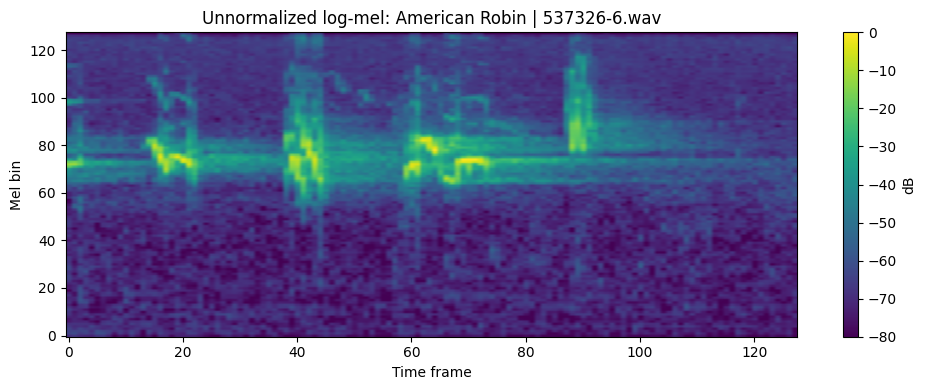

In [8]:
example_row = prepared["train"].sample(n=1, random_state=RANDOM_SEED).iloc[0]
example_wav_path = Path(example_row["wav_path"])

example_y, example_sr = load_fixed_audio(example_wav_path)
example_spec_db = wav_to_logmel_db(example_wav_path)

print("Species:", example_row["name"])
print("Filename:", example_row["filename"])
print("Waveform shape:", example_y.shape)
print("Sample rate:", example_sr)
print("Duration:", len(example_y) / example_sr)
print("Waveform RMS:", waveform_rms(example_y))
print("Spectrogram shape:", example_spec_db.shape)
print(
    "Spectrogram dB range:",
    float(example_spec_db.min()),
    "to",
    float(example_spec_db.max()),
)

display(Audio(example_y, rate=example_sr))

plt.figure(figsize=(10, 4))
plt.imshow(example_spec_db, aspect="auto", origin="lower")
plt.title(f'Unnormalized log-mel: {example_row["name"]} | {example_row["filename"]}')
plt.xlabel("Time frame")
plt.ylabel("Mel bin")
plt.colorbar(label="dB")
plt.tight_layout()
plt.show()

## 6. Visual check across species

This section previews unnormalized spectrograms from all three species. Look
for recognizable time-frequency structure and obvious processing failures.

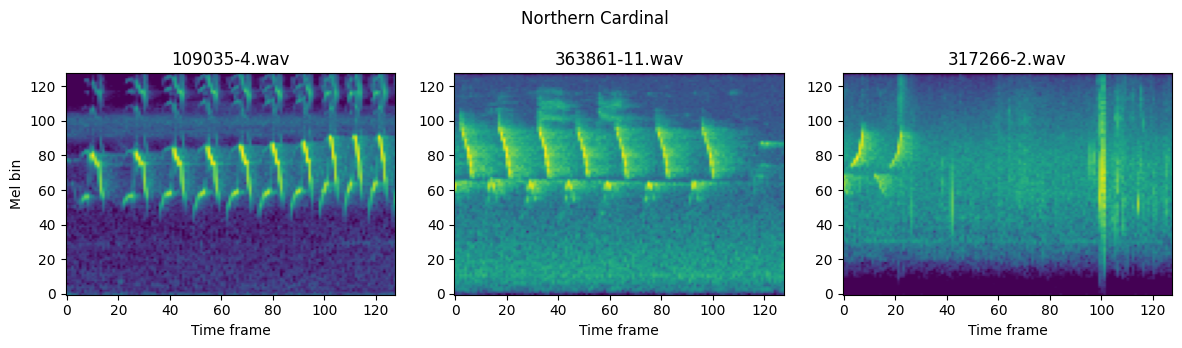

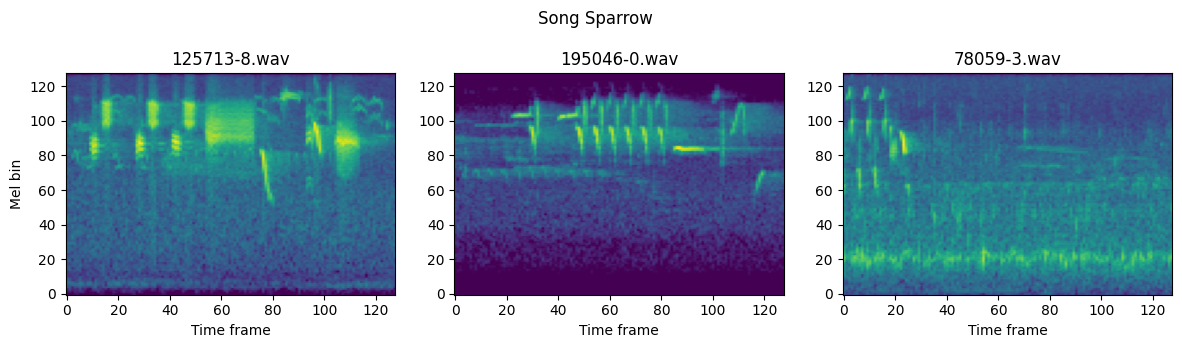

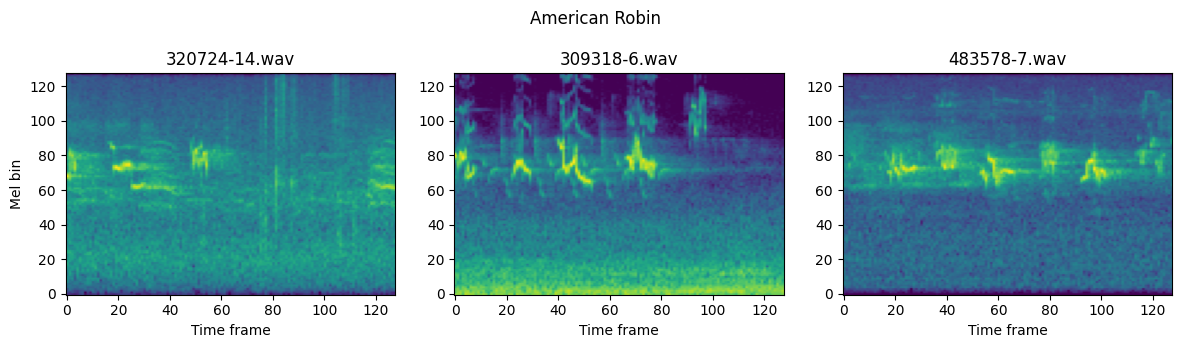

In [9]:
N_PREVIEW_PER_SPECIES = 3

for species in TARGET_SPECIES:
    species_df = prepared["train"][prepared["train"]["name"] == species]
    sample_rows = species_df.sample(
        n=min(N_PREVIEW_PER_SPECIES, len(species_df)),
        random_state=RANDOM_SEED,
    )

    plt.figure(figsize=(12, 3.5))
    for i, (_, row) in enumerate(sample_rows.iterrows(), start=1):
        spec_db = wav_to_logmel_db(Path(row["wav_path"]))
        ax = plt.subplot(1, len(sample_rows), i)
        image = ax.imshow(spec_db, aspect="auto", origin="lower")
        ax.set_title(row["filename"])
        ax.set_xlabel("Time frame")
        if i == 1:
            ax.set_ylabel("Mel bin")

    plt.suptitle(species)
    plt.tight_layout()
    plt.show()

## 7. Compute normalization statistics from the training split only

We use one global mean and standard deviation over all pixels in all training
spectrograms:

$$
x_{norm} = \frac{x_{dB} - \mu_{train}}{\sigma_{train}}
$$

Validation and test data do not contribute to these statistics. This avoids
preprocessing leakage.

The scan is performed in streaming form, so the notebook does not need to keep
the entire training set in memory.

In [10]:
def compute_streaming_normalization_stats(
    split_df: pd.DataFrame,
) -> tuple[dict, pd.DataFrame]:
    pixel_sum = 0.0
    pixel_square_sum = 0.0
    pixel_count = 0
    global_min = math.inf
    global_max = -math.inf
    failures = []

    for row in tqdm(
        split_df.itertuples(index=False),
        total=len(split_df),
        desc="Scanning training spectrograms",
    ):
        try:
            spec_db = wav_to_logmel_db(Path(row.wav_path))
            spec64 = spec_db.astype(np.float64, copy=False)

            pixel_sum += float(spec64.sum())
            pixel_square_sum += float(np.square(spec64).sum())
            pixel_count += int(spec64.size)
            global_min = min(global_min, float(spec64.min()))
            global_max = max(global_max, float(spec64.max()))
        except Exception as exc:
            failures.append({
                "split": row.split,
                "filename": row.filename,
                "wav_path": str(row.wav_path),
                "stage": "normalization_scan",
                "error": repr(exc),
            })

    if pixel_count == 0:
        raise RuntimeError("No training pixels were successfully processed.")

    mean = pixel_sum / pixel_count
    variance = max(pixel_square_sum / pixel_count - mean**2, 0.0)
    std = math.sqrt(variance)

    if not np.isfinite(mean) or not np.isfinite(std) or std < NORMALIZATION_EPS:
        raise RuntimeError(
            f"Invalid normalization statistics: mean={mean}, std={std}"
        )

    stats = {
        "method": "global_train_mean_std",
        "mean_db": float(mean),
        "std_db": float(std),
        "min_db_observed": float(global_min),
        "max_db_observed": float(global_max),
        "num_training_clips": int(len(split_df) - len(failures)),
        "num_training_pixels": int(pixel_count),
    }
    return stats, pd.DataFrame(failures)


normalization_stats, normalization_scan_failures = (
    compute_streaming_normalization_stats(prepared["train"])
)

print(json.dumps(normalization_stats, indent=2))
print("Normalization-scan failures:", len(normalization_scan_failures))
if len(normalization_scan_failures):
    display(normalization_scan_failures.head(20))

Scanning training spectrograms: 100%|██████████| 2339/2339 [00:22<00:00, 104.81it/s]

{
  "method": "global_train_mean_std",
  "mean_db": -51.5400096102764,
  "std_db": 14.894513218933453,
  "min_db_observed": -80.0,
  "max_db_observed": 0.0,
  "num_training_clips": 2339,
  "num_training_pixels": 38322176
}
Normalization-scan failures: 0


In [11]:
NORMALIZATION_STATS_PATH = PROCESSED_ROOT / "normalization_stats.json"

with open(NORMALIZATION_STATS_PATH, "w", encoding="utf-8") as file:
    json.dump(normalization_stats, file, indent=2)

TRAIN_MEAN_DB = normalization_stats["mean_db"]
TRAIN_STD_DB = normalization_stats["std_db"]

print("Saved:", NORMALIZATION_STATS_PATH.resolve())

Saved: C:\Users\sheng\Documents\1508_project\bird_song_gen\processed\normalization_stats.json


## 8. Normalize one preview sample

The normalized spectrogram should have approximately zero-centered values.
Individual clips do not need to have exactly zero mean or unit variance because
the statistics are global across the complete training split.

Normalized shape: (128, 128)
Normalized mean: -0.8311229944229126
Normalized std: 0.8247801661491394
Normalized range: -1.9107701778411865 to 3.4603352546691895


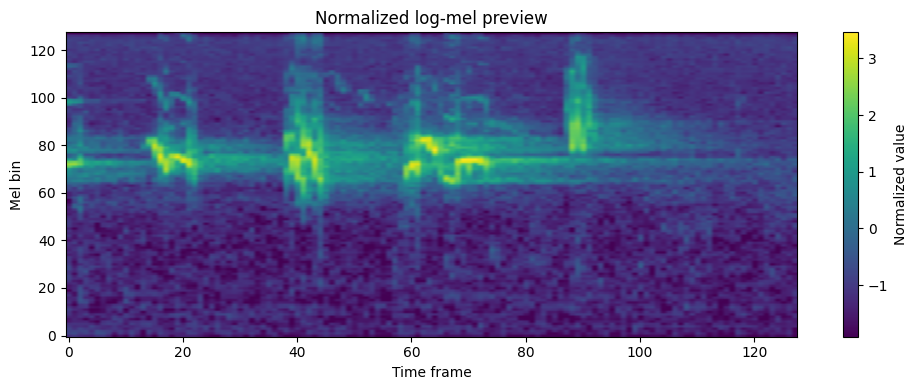

In [12]:
def normalize_logmel(spec_db: np.ndarray) -> np.ndarray:
    normalized = (spec_db - TRAIN_MEAN_DB) / (TRAIN_STD_DB + NORMALIZATION_EPS)
    normalized = normalized.astype(OUTPUT_DTYPE, copy=False)

    if not np.isfinite(normalized).all():
        raise ValueError("Normalization produced non-finite values.")

    return normalized


example_spec_norm = normalize_logmel(example_spec_db)

print("Normalized shape:", example_spec_norm.shape)
print("Normalized mean:", float(example_spec_norm.mean()))
print("Normalized std:", float(example_spec_norm.std()))
print(
    "Normalized range:",
    float(example_spec_norm.min()),
    "to",
    float(example_spec_norm.max()),
)

plt.figure(figsize=(10, 4))
plt.imshow(example_spec_norm, aspect="auto", origin="lower")
plt.title("Normalized log-mel preview")
plt.xlabel("Time frame")
plt.ylabel("Mel bin")
plt.colorbar(label="Normalized value")
plt.tight_layout()
plt.show()

## 9. Process and save every split

Each saved array has:

```text
dtype: float32
shape: (1, 128, 128)
axis 0: channel
axis 1: mel-frequency bin
axis 2: time frame
```

The code is restart-friendly. When `OVERWRITE_EXISTING = False`, an existing
valid tensor is reused rather than recomputed.

In [20]:
EXPECTED_TENSOR_SHAPE = (1, N_MELS, TARGET_FRAMES)


def load_and_validate_saved_tensor(path: Path) -> np.ndarray:
    tensor = np.load(path, allow_pickle=False)
    if tensor.shape != EXPECTED_TENSOR_SHAPE:
        raise ValueError(
            f"Saved tensor has shape {tensor.shape}; expected {EXPECTED_TENSOR_SHAPE}"
        )
    if tensor.dtype != OUTPUT_DTYPE:
        tensor = tensor.astype(OUTPUT_DTYPE)
    if not np.isfinite(tensor).all():
        raise ValueError("Saved tensor contains non-finite values.")
    return tensor


def process_split(
    split_df: pd.DataFrame,
    overwrite: bool = OVERWRITE_EXISTING,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    output_rows = []
    failure_rows = []

    for row in tqdm(
        split_df.itertuples(index=False),
        total=len(split_df),
        desc=f"Processing {split_df['split'].iloc[0]}",
    ):
        wav_path = Path(row.wav_path)
        spec_path = Path(row.spec_path)

        try:
            spec_path.parent.mkdir(parents=True, exist_ok=True)

            if spec_path.exists() and not overwrite:
                tensor = load_and_validate_saved_tensor(spec_path)
                processing_status = "reused"
            else:
                spec_db = wav_to_logmel_db(wav_path)
                spec_norm = normalize_logmel(spec_db)
                tensor = spec_norm[np.newaxis, :, :].astype(
                    OUTPUT_DTYPE,
                    copy=False,
                )

                if tensor.shape != EXPECTED_TENSOR_SHAPE:
                    raise ValueError(
                        f"Output tensor has shape {tensor.shape}; "
                        f"expected {EXPECTED_TENSOR_SHAPE}"
                    )

                np.save(spec_path, tensor, allow_pickle=False)
                processing_status = "written"

            output_row = row._asdict()
            output_row.update({
                "processing_status": processing_status,
                "tensor_shape": "1x128x128",
                "tensor_dtype": str(tensor.dtype),
                "tensor_min": float(tensor.min()),
                "tensor_max": float(tensor.max()),
                "tensor_mean": float(tensor.mean()),
                "tensor_std": float(tensor.std()),
            })
            output_rows.append(output_row)

        except Exception as exc:
            failure_rows.append({
                "split": getattr(row, "split", None),
                "name": getattr(row, "name", None),
                "id": getattr(row, "id", None),
                "filename": getattr(row, "filename", None),
                "wav_path": str(wav_path),
                "spec_path": str(spec_path),
                "stage": "full_preprocessing",
                "error": repr(exc),
            })

    return pd.DataFrame(output_rows), pd.DataFrame(failure_rows)

In [21]:
processed_splits = {}
processing_failures = []

for split in ["train", "validation", "test"]:
    processed_df, failure_df = process_split(prepared[split])
    processed_splits[split] = processed_df
    if len(failure_df):
        processing_failures.append(failure_df)

if processing_failures:
    processing_failures_df = pd.concat(processing_failures, ignore_index=True)
else:
    processing_failures_df = pd.DataFrame(
        columns=[
            "split", "name", "id", "filename", "wav_path",
            "spec_path", "stage", "error",
        ]
    )

all_failures_df = pd.concat(
    [
        normalization_scan_failures,
        processing_failures_df,
    ],
    ignore_index=True,
    sort=False,
)

FAILURE_REPORT_PATH = REPORT_DIR / "preprocessing_failures.csv"
all_failures_df.to_csv(FAILURE_REPORT_PATH, index=False)

print("Total failures:", len(all_failures_df))
print("Failure report:", FAILURE_REPORT_PATH.resolve())
if len(all_failures_df):
    display(all_failures_df.head(20))

Processing test: 100%|██████████| 489/489 [00:05<00:00, 89.44it/s] 

Total failures: 0
Failure report: C:\Users\sheng\Documents\1508_project\bird_song_gen\processed\reports\preprocessing_failures.csv


## 10. Save processed manifests and label mapping

Downstream notebooks should read these processed manifests rather than the raw
manifests from notebook 01.

Important columns:

- `name`: species name
- `label_id`: integer conditioning/classification label
- `relative_wav_path`: original audio
- `relative_spec_path`: normalized tensor
- `split`: fixed data split

In [22]:
def make_portable_manifest(processed_df: pd.DataFrame) -> pd.DataFrame:
    out = processed_df.copy()

    # Remove machine-specific absolute path columns.
    drop_columns = ["wav_path", "spec_path", "wav_exists"]
    out = out.drop(columns=[c for c in drop_columns if c in out.columns])

    preferred_columns = [
        "split",
        "name",
        "label_id",
        "species_slug",
        "genus",
        "species",
        "id",
        "filename",
        "relative_wav_path",
        "relative_spec_path",
        "processing_status",
        "tensor_shape",
        "tensor_dtype",
        "tensor_min",
        "tensor_max",
        "tensor_mean",
        "tensor_std",
    ]
    remaining_columns = [
        c for c in out.columns if c not in preferred_columns
    ]
    ordered_columns = [
        c for c in preferred_columns if c in out.columns
    ] + remaining_columns

    return (
        out[ordered_columns]
        .sort_values(["name", "id", "filename"])
        .reset_index(drop=True)
    )


portable_manifests = {
    split: make_portable_manifest(processed_df)
    for split, processed_df in processed_splits.items()
}

processed_manifest_paths = {
    "train": PROCESSED_MANIFEST_DIR / "logmel_128_train.csv",
    "validation": PROCESSED_MANIFEST_DIR / "logmel_128_validation.csv",
    "test": PROCESSED_MANIFEST_DIR / "logmel_128_test.csv",
}

for split, output_path in processed_manifest_paths.items():
    portable_manifests[split].to_csv(output_path, index=False)
    print("Saved:", output_path.resolve())

full_processed_manifest = pd.concat(
    [
        portable_manifests["train"],
        portable_manifests["validation"],
        portable_manifests["test"],
    ],
    ignore_index=True,
)

FULL_PROCESSED_MANIFEST_PATH = (
    PROCESSED_MANIFEST_DIR / "logmel_128_full.csv"
)
full_processed_manifest.to_csv(
    FULL_PROCESSED_MANIFEST_PATH,
    index=False,
)

label_map_df = pd.DataFrame({
    "label_id": list(LABEL_TO_SPECIES.keys()),
    "species_name": list(LABEL_TO_SPECIES.values()),
})
LABEL_MAP_PATH = PROCESSED_ROOT / "label_map.csv"
label_map_df.to_csv(LABEL_MAP_PATH, index=False)

print("Saved:", FULL_PROCESSED_MANIFEST_PATH.resolve())
print("Saved:", LABEL_MAP_PATH.resolve())
display(label_map_df)

Saved: C:\Users\sheng\Documents\1508_project\bird_song_gen\processed\manifests\logmel_128_train.csv
Saved: C:\Users\sheng\Documents\1508_project\bird_song_gen\processed\manifests\logmel_128_validation.csv
Saved: C:\Users\sheng\Documents\1508_project\bird_song_gen\processed\manifests\logmel_128_test.csv
Saved: C:\Users\sheng\Documents\1508_project\bird_song_gen\processed\manifests\logmel_128_full.csv
Saved: C:\Users\sheng\Documents\1508_project\bird_song_gen\processed\label_map.csv


,label_id,species_name
0,0,Northern Cardinal
1,1,Song Sparrow
2,2,American Robin


## 11. Save the preprocessing configuration

The configuration file records every parameter required to reproduce the model
inputs. Later notebooks should load this file rather than redefining the
spectrogram parameters independently.

In [23]:
preprocessing_config = {
    "target_species": TARGET_SPECIES,
    "species_to_label": SPECIES_TO_LABEL,
    "audio": {
        "target_sample_rate_hz": TARGET_SR,
        "clip_duration_sec": CLIP_DURATION_SEC,
        "target_num_samples": TARGET_NUM_SAMPLES,
        "mono": True,
        "long_clip_policy": "take_first_target_num_samples",
        "short_clip_policy": "zero_pad_at_end",
    },
    "logmel": {
        "n_mels": N_MELS,
        "n_fft": N_FFT,
        "hop_length": HOP_LENGTH,
        "target_frames": TARGET_FRAMES,
        "fmin_hz": FMIN,
        "fmax_hz": FMAX,
        "power": POWER,
        "top_db": TOP_DB,
        "center": CENTER,
        "db_reference": "per_clip_maximum",
    },
    "normalization": normalization_stats,
    "output": {
        "shape": list(EXPECTED_TENSOR_SHAPE),
        "dtype": str(np.dtype(OUTPUT_DTYPE)),
        "file_format": "npy",
        "channel_order": "channel_mel_time",
    },
    "input_manifests": {
        split: str(path.relative_to(PROJECT_ROOT))
        for split, path in manifest_paths.items()
    },
    "output_manifests": {
        split: str(path.relative_to(PROJECT_ROOT))
        for split, path in processed_manifest_paths.items()
    },
}

PREPROCESSING_CONFIG_PATH = PROCESSED_ROOT / "preprocessing_config.json"
with open(PREPROCESSING_CONFIG_PATH, "w", encoding="utf-8") as file:
    json.dump(preprocessing_config, file, indent=2)

print("Saved:", PREPROCESSING_CONFIG_PATH.resolve())
print(json.dumps(preprocessing_config, indent=2))

Saved: C:\Users\sheng\Documents\1508_project\bird_song_gen\processed\preprocessing_config.json
{
  "target_species": [
    "Northern Cardinal",
    "Song Sparrow",
    "American Robin"
  ],
  "species_to_label": {
    "Northern Cardinal": 0,
    "Song Sparrow": 1,
    "American Robin": 2
  },
  "audio": {
    "target_sample_rate_hz": 22050,
    "clip_duration_sec": 3.0,
    "target_num_samples": 66150,
    "mono": true,
    "long_clip_policy": "take_first_target_num_samples",
    "short_clip_policy": "zero_pad_at_end"
  },
  "logmel": {
    "n_mels": 128,
    "n_fft": 1024,
    "hop_length": 512,
    "target_frames": 128,
    "fmin_hz": 0.0,
    "fmax_hz": 11025.0,
    "power": 2.0,
    "top_db": 80.0,
    "center": false,
    "db_reference": "per_clip_maximum"
  },
  "normalization": {
    "method": "global_train_mean_std",
    "mean_db": -51.5400096102764,
    "std_db": 14.894513218933453,
    "min_db_observed": -80.0,
    "max_db_observed": 0.0,
    "num_training_clips": 2339,
    "

## 12. Final verification

This section confirms:

- processed file counts match successful manifest rows;
- every sampled tensor has shape `1 × 128 × 128`;
- every sampled tensor is finite and `float32`;
- all three labels remain present in every split;
- saved tensors can be loaded by downstream notebooks.

In [24]:
verification_rows = []

for split, manifest_df in portable_manifests.items():
    expected_count = len(manifest_df)
    existing_count = 0
    invalid_count = 0

    for relative_path in tqdm(
        manifest_df["relative_spec_path"],
        desc=f"Verifying {split}",
    ):
        path = PROJECT_ROOT / Path(relative_path)
        if not path.exists():
            invalid_count += 1
            continue

        try:
            tensor = load_and_validate_saved_tensor(path)
            existing_count += 1
        except Exception:
            invalid_count += 1

    verification_rows.append({
        "split": split,
        "manifest_rows": expected_count,
        "valid_saved_tensors": existing_count,
        "invalid_or_missing_tensors": invalid_count,
        "species_count": manifest_df["name"].nunique(),
        "label_count": manifest_df["label_id"].nunique(),
    })

verification_df = pd.DataFrame(verification_rows)
display(verification_df)

assert (verification_df["invalid_or_missing_tensors"] == 0).all()
assert (verification_df["manifest_rows"] == verification_df["valid_saved_tensors"]).all()
assert (verification_df["species_count"] == len(TARGET_SPECIES)).all()
assert (verification_df["label_count"] == len(TARGET_SPECIES)).all()

print("Final structural verification passed.")

Verifying test: 100%|██████████| 489/489 [00:00<00:00, 6434.11it/s]


,split,manifest_rows,valid_saved_tensors,invalid_or_missing_tensors,species_count,label_count
0,train,2339,2339,0,3,3
1,validation,519,519,0,3,3
2,test,489,489,0,3,3


Final structural verification passed.


In [25]:
# Aggregate normalized-value summaries by split.
value_summary_rows = []

for split, manifest_df in portable_manifests.items():
    value_summary_rows.append({
        "split": split,
        "num_tensors": len(manifest_df),
        "mean_of_tensor_means": manifest_df["tensor_mean"].mean(),
        "mean_of_tensor_stds": manifest_df["tensor_std"].mean(),
        "minimum_value": manifest_df["tensor_min"].min(),
        "maximum_value": manifest_df["tensor_max"].max(),
    })

value_summary_df = pd.DataFrame(value_summary_rows)
display(value_summary_df)

,split,num_tensors,mean_of_tensor_means,mean_of_tensor_stds,minimum_value,maximum_value
0,train,2339,-7.568360e-08,0.800965,-1.91077,3.460335
1,validation,519,1.585219e-01,0.795330,-1.91077,3.460335
2,test,489,3.608214e-02,0.810699,-1.91077,3.460335


## 13. Random processed-tensor visualization

These plots load the final `.npy` files, not the WAV files. Therefore, this is
also an end-to-end check that the saved representation is usable.

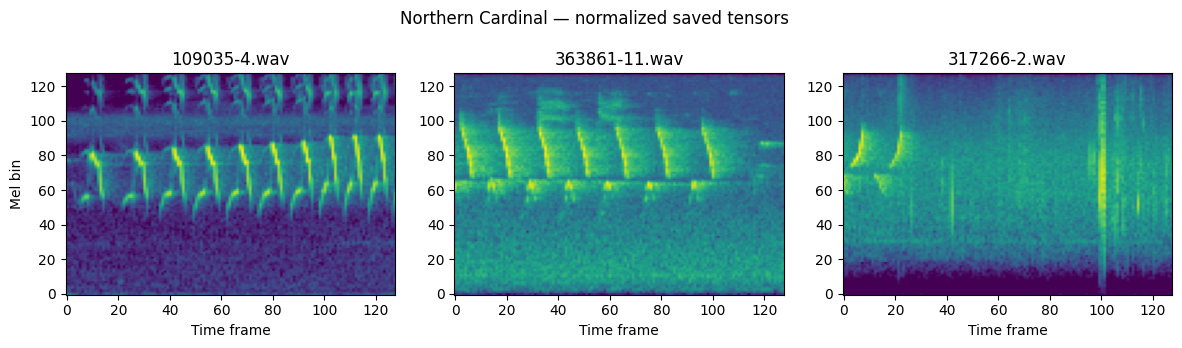

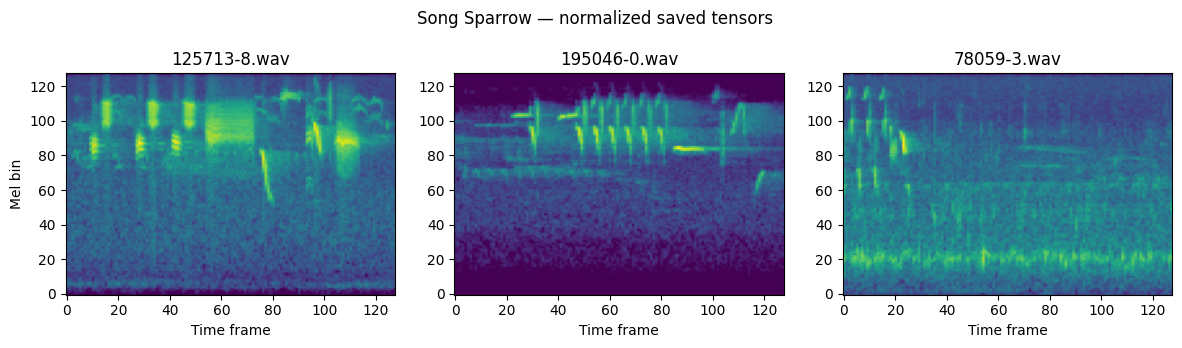

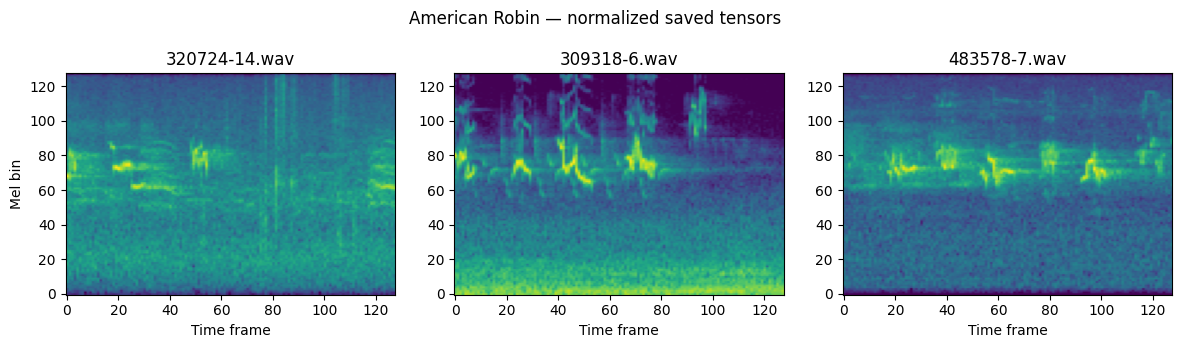

In [26]:
N_FINAL_PREVIEWS_PER_SPECIES = 3
train_processed = portable_manifests["train"]

for species in TARGET_SPECIES:
    species_df = train_processed[train_processed["name"] == species]
    sample_rows = species_df.sample(
        n=min(N_FINAL_PREVIEWS_PER_SPECIES, len(species_df)),
        random_state=RANDOM_SEED,
    )

    plt.figure(figsize=(12, 3.5))
    for i, (_, row) in enumerate(sample_rows.iterrows(), start=1):
        tensor_path = PROJECT_ROOT / Path(row["relative_spec_path"])
        tensor = np.load(tensor_path, allow_pickle=False)

        ax = plt.subplot(1, len(sample_rows), i)
        ax.imshow(tensor[0], aspect="auto", origin="lower")
        ax.set_title(row["filename"])
        ax.set_xlabel("Time frame")
        if i == 1:
            ax.set_ylabel("Mel bin")

    plt.suptitle(f"{species} — normalized saved tensors")
    plt.tight_layout()
    plt.show()

## 14. Output checklist

After a successful run, confirm:

- [ ] Training-only normalization statistics were saved.
- [ ] Every output tensor has shape `(1, 128, 128)`.
- [ ] Every output tensor uses `float32`.
- [ ] No non-finite values were found.
- [ ] Processed counts match the input manifests, except documented failures.
- [ ] Processed manifests contain both `label_id` and `relative_spec_path`.
- [ ] `preprocessing_config.json` records all transform parameters.
- [ ] Random saved tensors show plausible bird-song time-frequency structure.

Downstream notebooks should use:

```text
processed/manifests/logmel_128_train.csv
processed/manifests/logmel_128_validation.csv
processed/manifests/logmel_128_test.csv
processed/preprocessing_config.json
processed/normalization_stats.json
```

Next notebook: `03_classifier_baseline.ipynb`.